## 5. Visualize the knowledge graph

This section creates a set of visual summaries to make the processed PrimeKG graph easier to inspect and explain.


### Helper functions used throughout the block

Several small helper functions are defined to keep the code cleaner and make the visualizations more readable:

- **`normalize_text()`** standardizes names by lowercasing text and replacing underscores with spaces. This makes matching user-defined query strings more reliable.
- **`wrap_label()`** formats long node names so they fit better inside graph nodes when plotted.
- **`find_best_node()`** searches the node table for the best match to a disease or drug name. It prioritizes exact matches over partial matches and prefers more specific source entries over grouped entries.
- **`column_positions()`** assigns evenly spaced coordinates to nodes in vertical columns. This is used for the cleaner multi-column publication-style graph layouts later in the block.
- **`sorted_by_name()`** sorts node IDs alphabetically based on display names, which helps keep the figures deterministic and visually organized.

A reusable lookup table from `node_uid` to `node_name` is also created so that node labels can be retrieved quickly during plotting.

### Color design

To make the graphs easier to interpret, the block defines shared color palettes for both node types and edge types.  
Node colors are used to distinguish broad biomedical entities such as drugs, diseases, proteins, phenotypes, and side effects.  
Edge colors are used to separate relation types such as indication, contraindication, disease–protein association, and different drug–protein interaction subtypes.  
A separate curvature mapping is also defined so that multiple edge types between similar node groups can be drawn without overlapping too heavily.

### Figure 1: Schema graph

The first figure is a **schema-level graph** rather than a graph of individual biomedical entities. It shows the high-level structure of the knowledge graph by answering two questions:

1. What kinds of node types exist in the graph?
2. What kinds of relations connect them?


### Figure 2: Sample neighborhood graph

The second figure is a **small handcrafted example graph** built to illustrate how a typical biomedical neighborhood looks. Instead of depending on live query results, it uses a fixed set of representative nodes and relations so that the figure always renders clearly and consistently.

This figure is especially useful for presentations because it gives a simple, readable example of how one drug can connect to proteins, diseases, and other biomedical concepts without the noise of a larger real subgraph.

### Figure 3: Disease-centered real subgraph

The third figure moves from a fixed example to a **real subgraph extracted from the processed dataset**. It is centered on the disease specified in `DISEASE_QUERY`.

The code first identifies the matching disease node, then collects:

- all **1-hop neighbors**, meaning nodes directly connected to the disease
- a limited set of **2-hop neighbors**, which extends the neighborhood one step further while applying caps to reduce visual clutter

This gives a more realistic view of how a disease is embedded in the knowledge graph. The center disease node is drawn larger so that it stands out from surrounding nodes.

### Figure 4: Three-column graph layout

The fourth figure creates a more structured, publication-style **three-column layout** organized as:

**Drug → Protein/Gene → Disease**

This figure is centered on the drug defined in `CENTER_DRUG`. The block first locates that drug in the processed node table, then retrieves:

- protein nodes connected to the drug through different drug–protein relation types
- diseases associated with those proteins

To keep the figure readable, the code ranks proteins by connectivity and keeps the most informative ones. It then lays out the graph in three vertical columns so the biological flow is easy to follow from left to right. This view is useful because it shows a possible mechanistic path from a drug to diseases through intermediate protein interactions.

### Figure 5: Four-column graph layout

The fifth figure expands the previous idea into a richer **four-column layout**:

**Drug → Protein/Gene → Phenotype → Disease**

This figure is centered on the disease defined in `QUERY_4COL`. The graph is built outward in stages:

1. Find the central disease node
2. Retrieve related diseases through ontology hierarchy links
3. Collect phenotypes connected to the disease
4. Collect proteins connected to either the disease or its phenotypes
5. Collect drugs connected to those proteins
6. Overlay direct drug–disease relations such as **indication** and **contraindication**

This step-by-step expansion produces a more biologically expressive view of the graph by showing how drugs may connect to diseases through proteins and phenotypic effects, while also preserving known treatment or risk relationships.

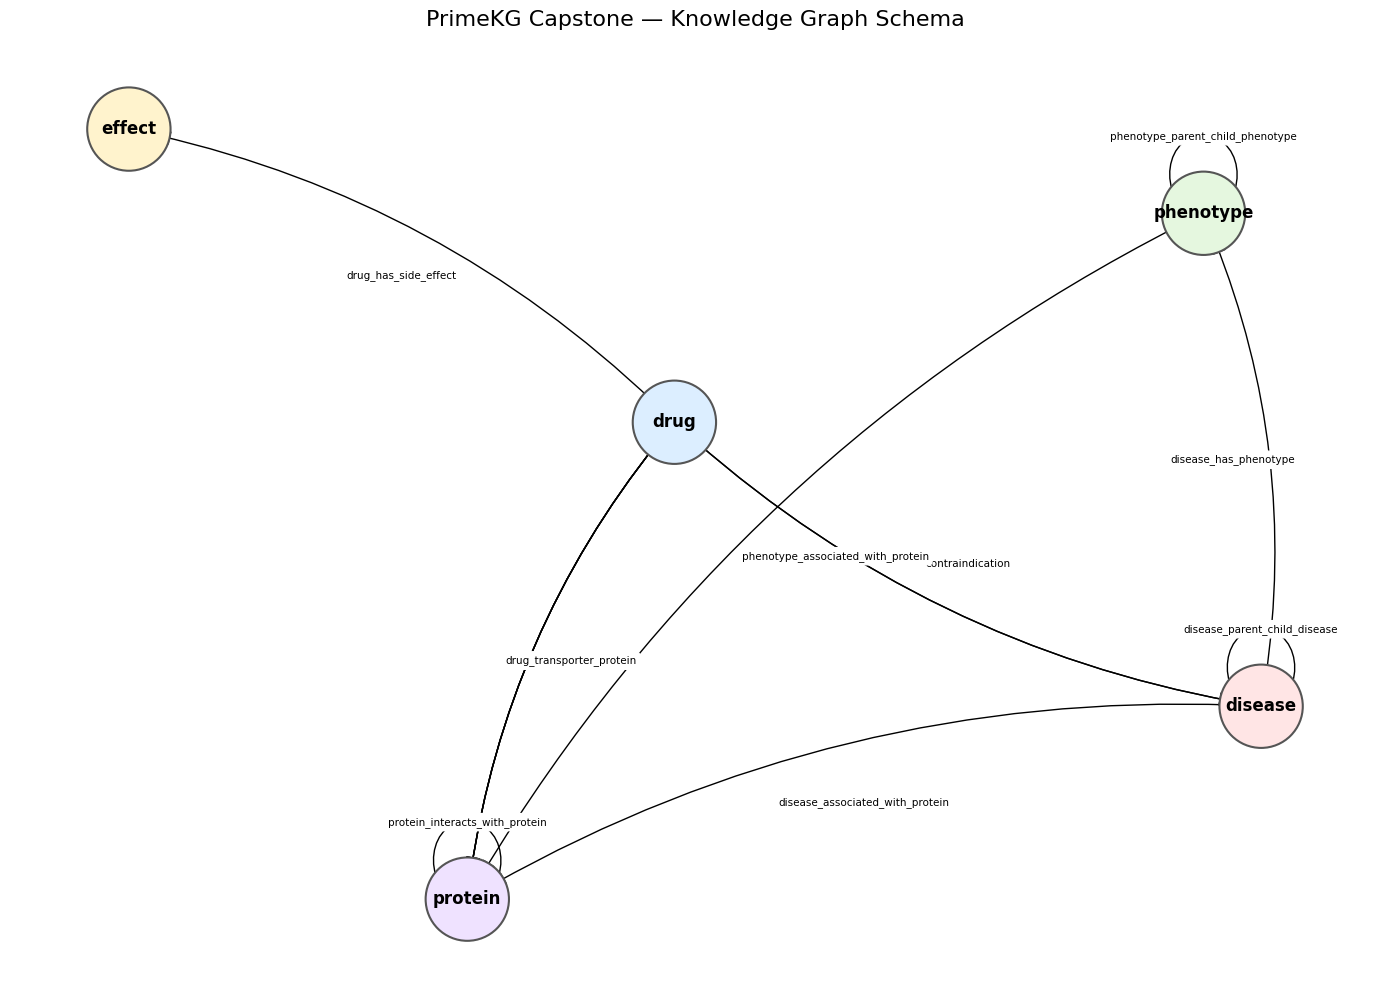

[Fig 1] Schema graph saved -> /mnt/data/fig1_schema_graph.png


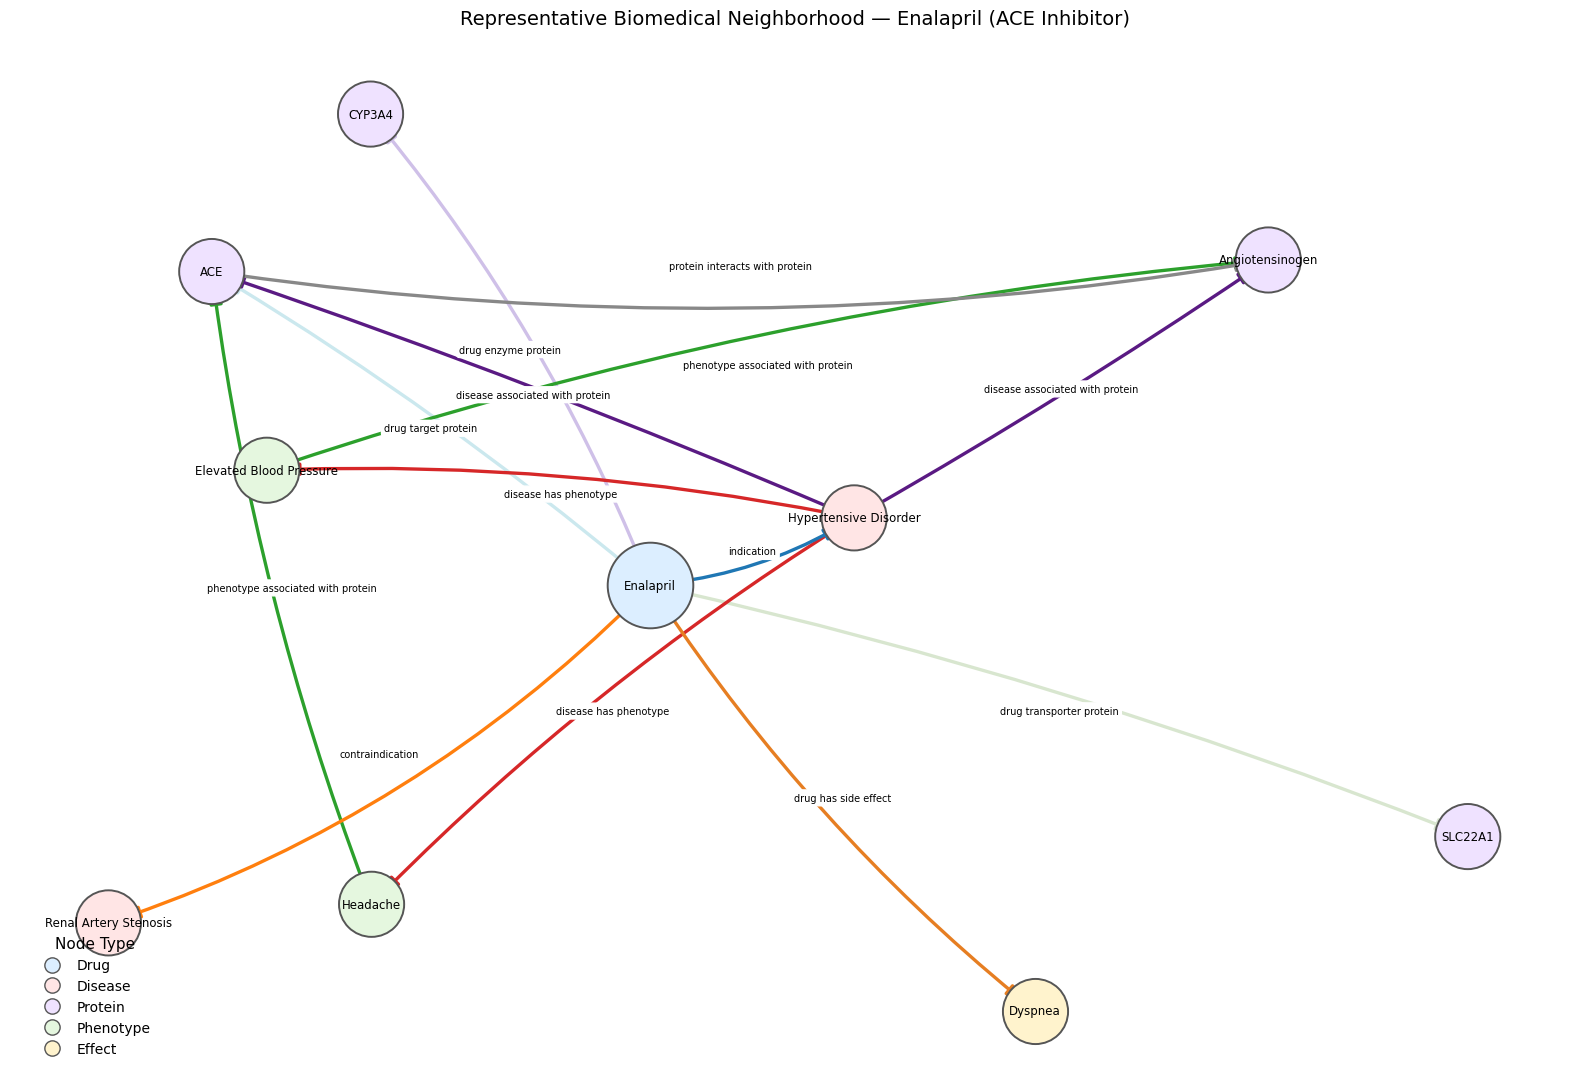

[Fig 2] Sample neighborhood saved -> /mnt/data/fig2_sample_neighborhood.png

[Fig 3] Center disease: hypertension  (disease:1200_1134_15512_5080_100078)
         Subgraph: 624 nodes, 753 edges


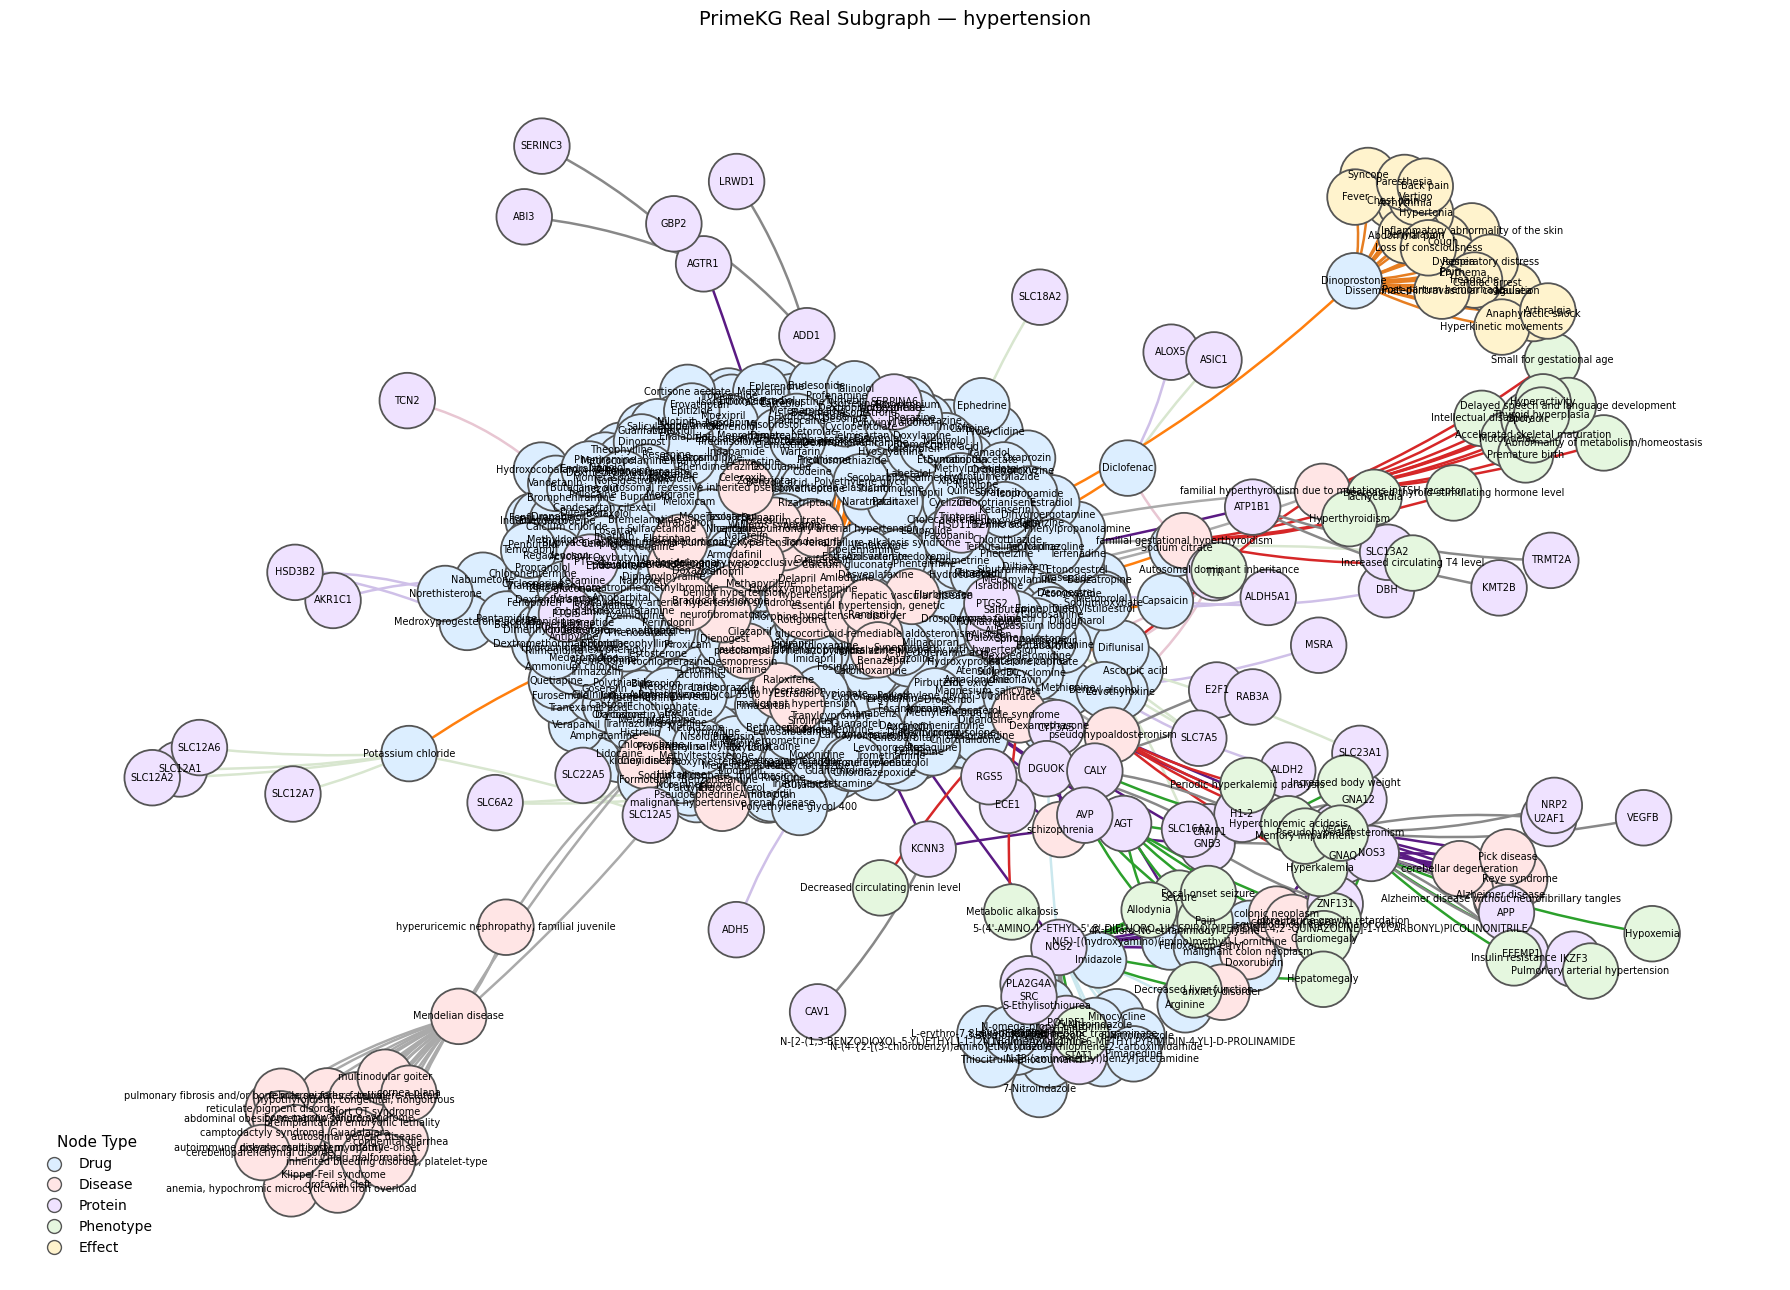

[Fig 3] Disease subgraph saved -> /mnt/data/fig3_subgraph_hypertension.png

[Fig 4] Center drug: Metformin  (drug:DB00331)
  Drug: 1, Proteins: 9, Diseases: 12


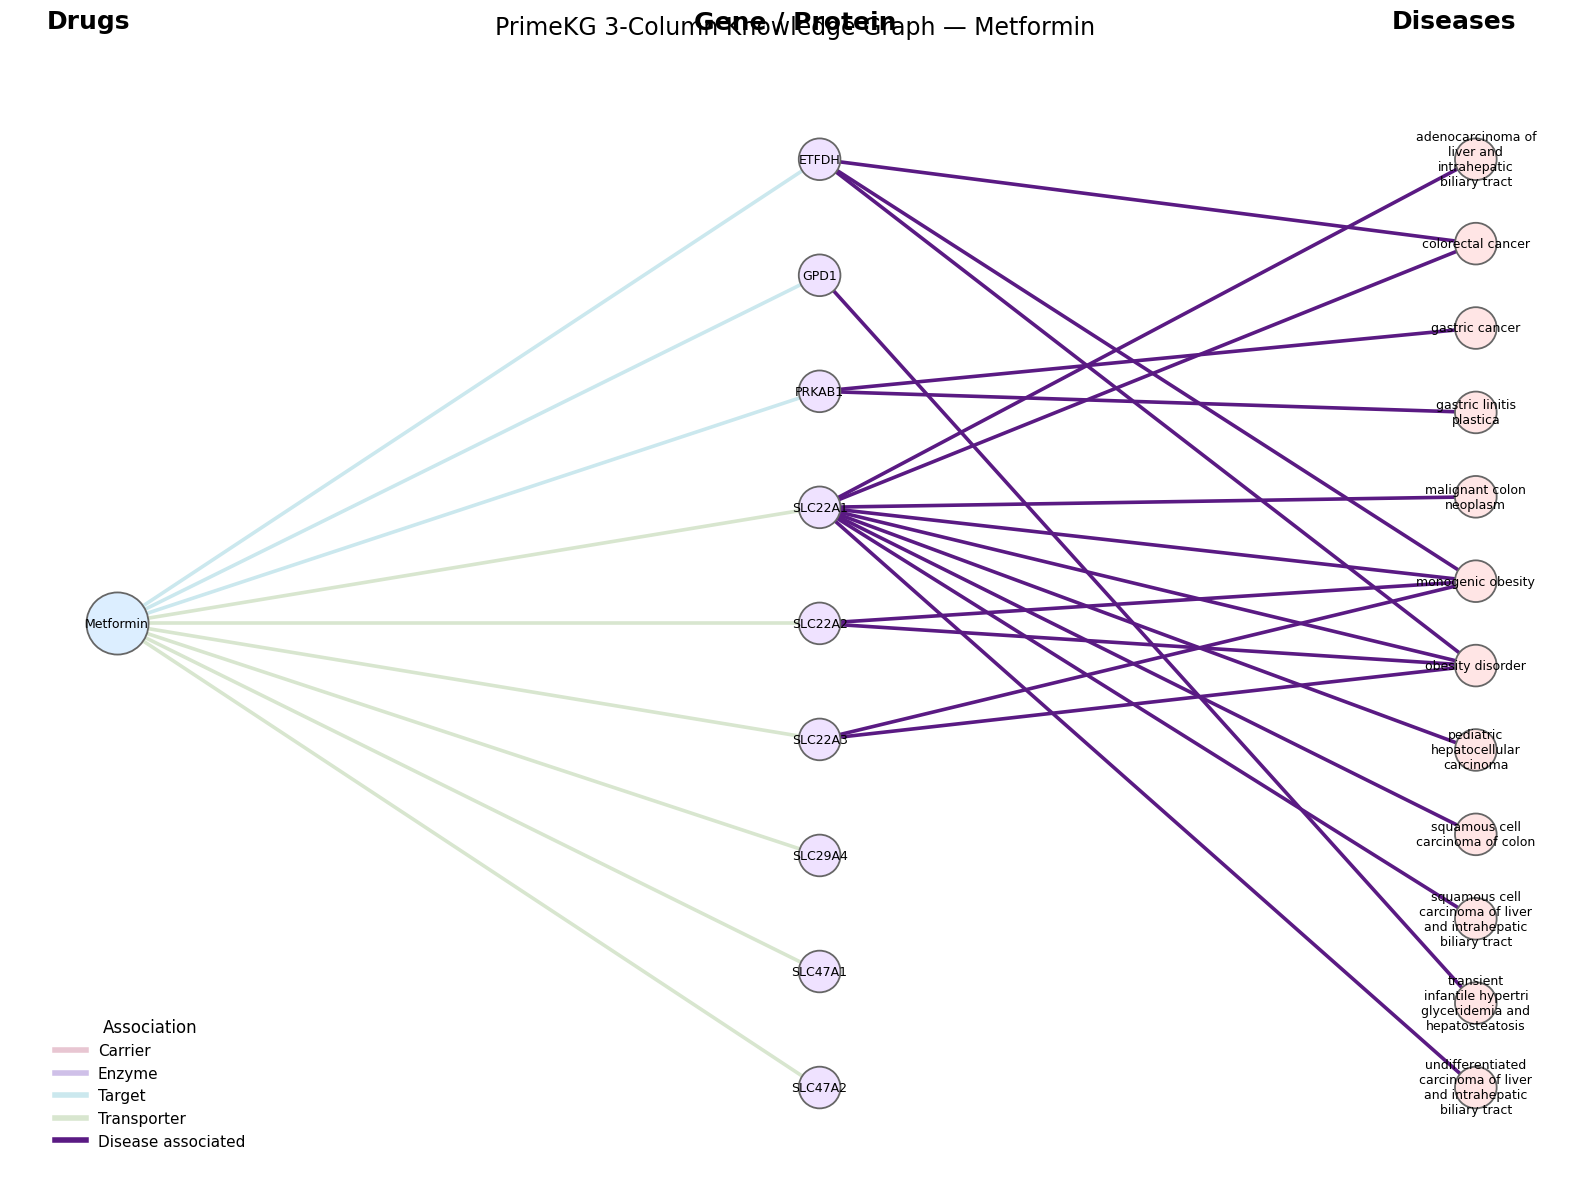

[Fig 4] 3-column KG saved -> /mnt/data/fig4_3column_kg.png

[Fig 5] Center disease: migraine disorder  (disease:5277)
  Drugs: 12, Proteins: 14, Phenotypes: 2, Diseases: 5


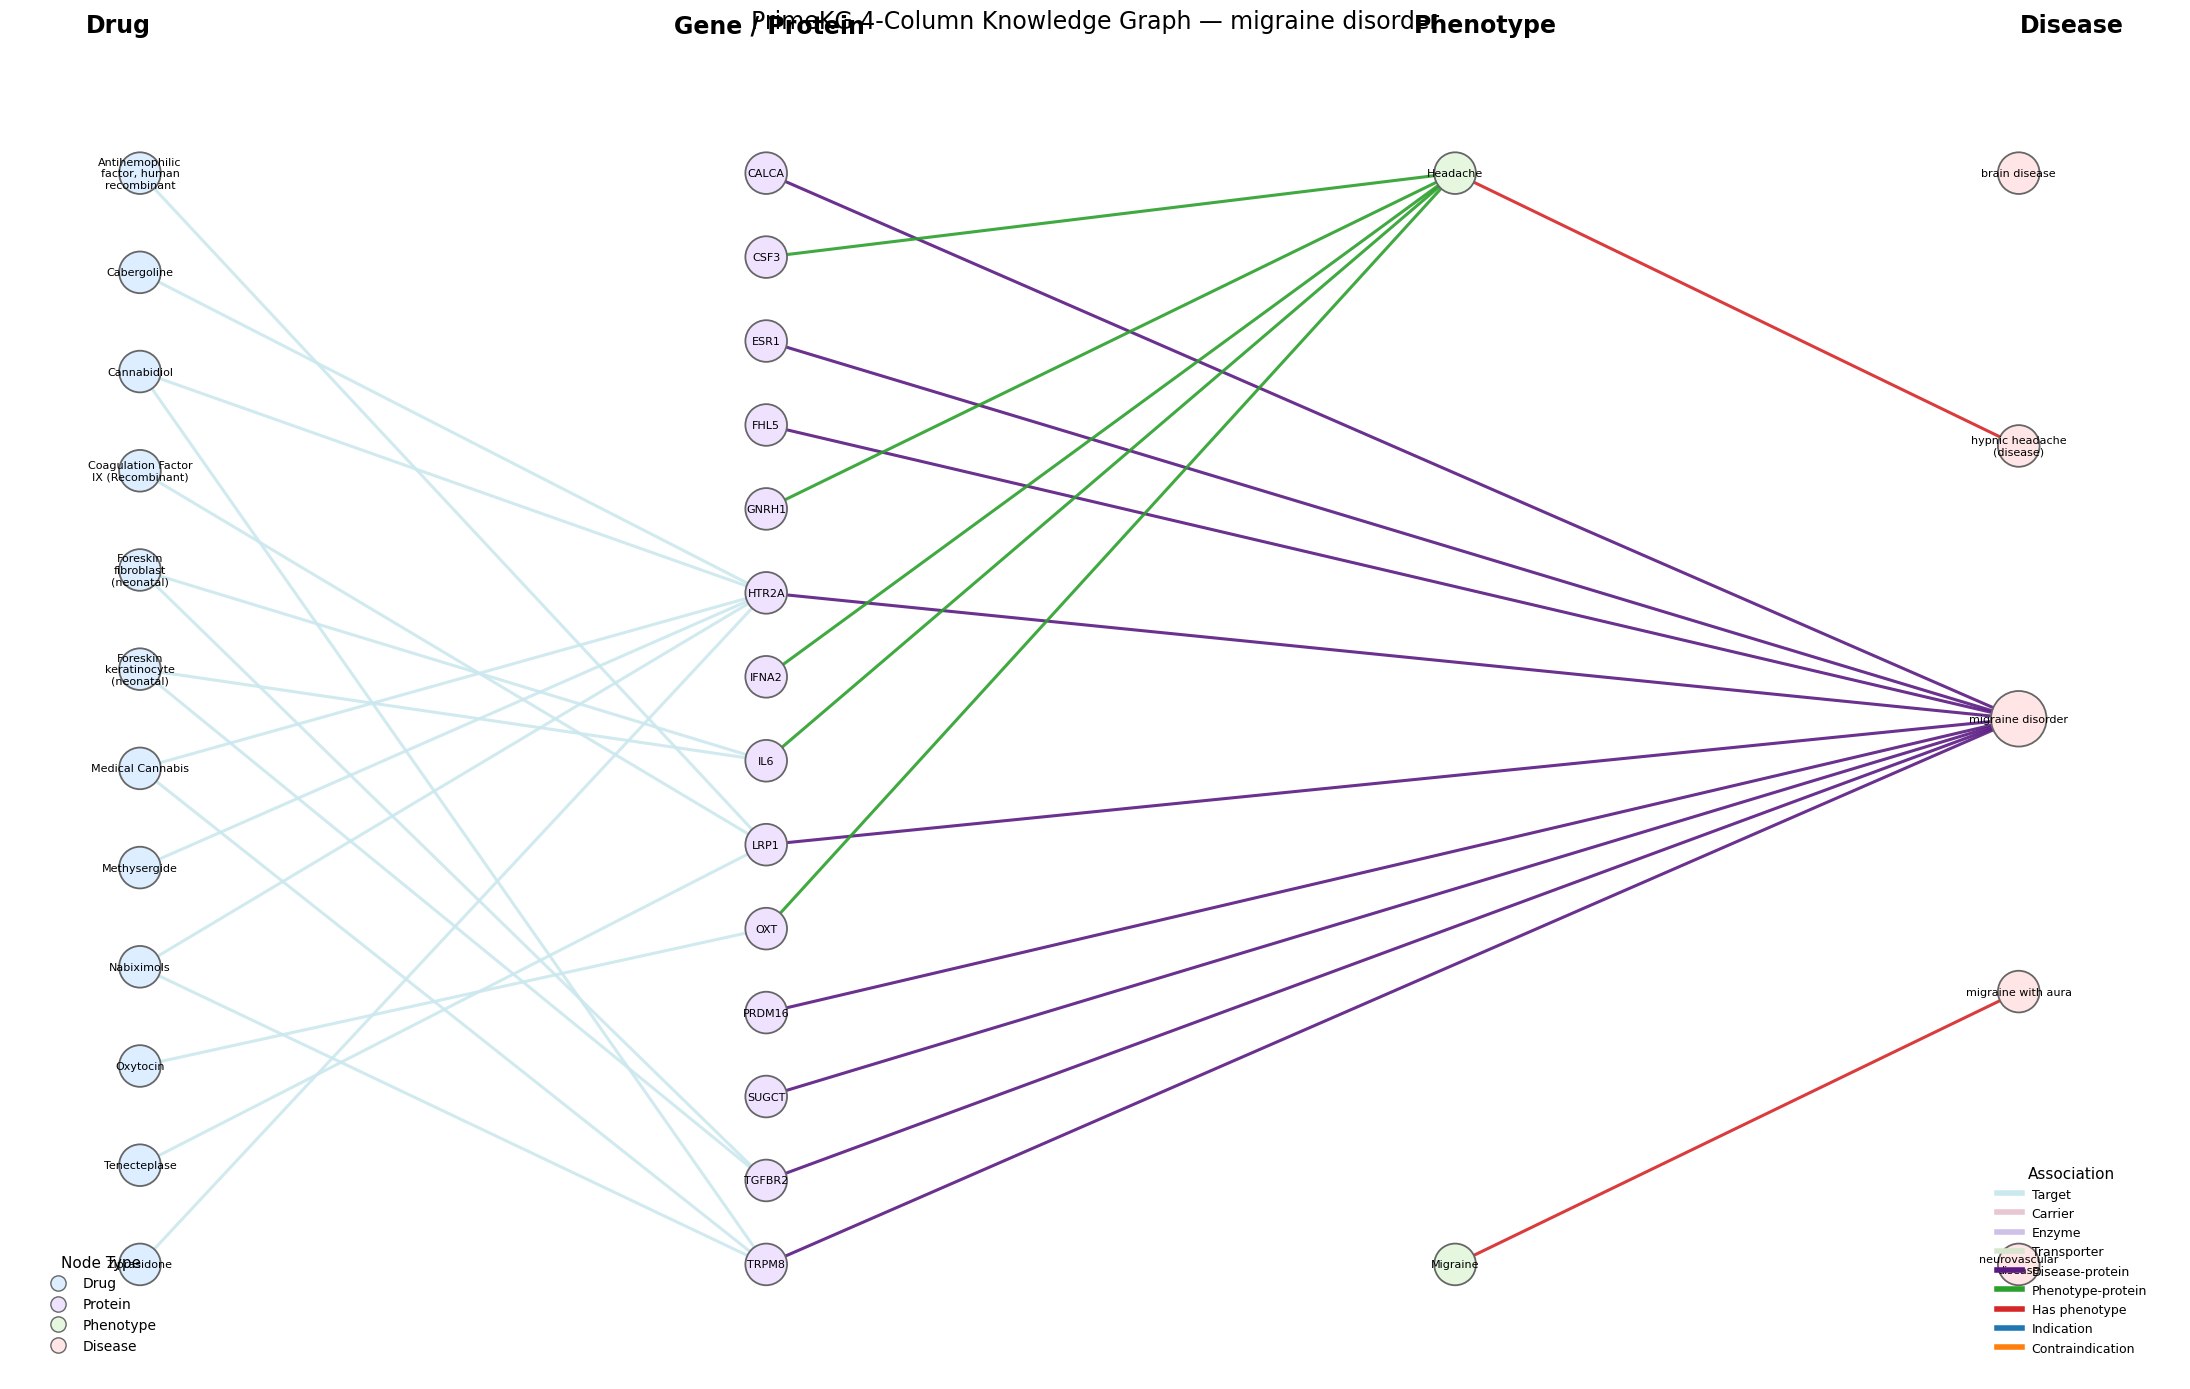

[Fig 5] 4-column KG saved -> /mnt/data/fig5_4column_kg.png

  BLOCK 05 COMPLETE
  Fig 1 : fig1_schema_graph.png  (schema)
  Fig 2 : fig2_sample_neighborhood.png  (sample neighborhood)
  Fig 3 : fig3_subgraph_hypertension.png  (real disease subgraph)
  Fig 4 : fig4_3column_kg.png  (3-column drug KG)
  Fig 5 : fig5_4column_kg.png  (4-column disease KG)


In [ ]:
# USER SETTINGS (change these at the top):
#   DISEASE_QUERY : disease name for Fig 3 subgraph
#   CENTER_DRUG   : drug name to center the Fig 4 3-column layout
#   QUERY_4COL    : disease name for Fig 5 4-column layout

assert "canonical_edges_df" in globals(), "Run Block 04 first."
assert "nodes_master_df"    in globals(), "Run Block 04 first."

# Output directory
OUTPUT_DIR = Path("/mnt/data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# User-configurable query strings
DISEASE_QUERY = "hypertension"   # Fig 3: disease-centered real subgraph
CENTER_DRUG   = "Metformin"      # Fig 4: drug for the 3-column layout
QUERY_4COL    = "migraine"       # Fig 5: disease for the 4-column layout


# Shared helpers

def normalize_text(text: str) -> str:
    """Lowercase, strip, replace underscores with spaces."""
    return str(text).lower().strip().replace("_", " ")

def wrap_label(text: str, width: int = 16) -> str:
    """Word-wrap a node label so it fits inside a drawn node circle."""
    return "\n".join(textwrap.wrap(str(text), width=width))

def find_best_node(df: pd.DataFrame, name_col: str, query: str):
    """
    Search df for the best-matching node by name.
    Returns a single pd.Series (the matched row) or None.
    Priority: exact match > contains match, then non-grouped source,
    then shortest name (least ambiguous), then alphabetical.
    """
    q    = normalize_text(query)
    work = df.copy()
    work["_norm"]    = work[name_col].apply(normalize_text)
    work["_len"]     = work[name_col].str.len()
    # Grouped sources are PrimeKG cross-database aggregations;
    work["_grouped"] = work["node_source"].str.contains(
        "grouped", case=False, na=False
    ).astype(int)

    exact    = work[work["_norm"] == q]
    contains = work[work["_norm"].str.contains(q, na=False)]
    pool     = exact if not exact.empty else contains

    if pool.empty:
        return None

    return pool.sort_values(
        ["_grouped", "_len", name_col],
        ascending=[True, True, True],
    ).iloc[0]

def column_positions(
    node_list: list,
    x: float,
    y_top: float = 0.92,
    y_bottom: float = 0.08,
) -> dict:
    """
    Assign evenly-spaced (x, y) positions along a vertical column.
    Used to produce the clean multi-column KG layouts.
    """
    n = len(node_list)
    if n == 0:
        return {}
    if n == 1:
        return {node_list[0]: (x, 0.5)}
    step = (y_top - y_bottom) / (n - 1)
    ys   = list(reversed([y_bottom + i * step for i in range(n)]))
    return {node: (x, y) for node, y in zip(node_list, ys)}

def sorted_by_name(uid_list: list, name_lookup: dict) -> list:
    """Sort a list of UIDs alphabetically by their display names."""
    return sorted(uid_list, key=lambda u: name_lookup.get(u, u))

# Build a UID -> name lookup reused throughout this block
_uid_to_name = dict(
    zip(nodes_master_df["node_uid"], nodes_master_df["node_name"])
)

# Shared color palettes used across all figures
_NODE_COLORS = {
    "drug":      "#dceeff",
    "disease":   "#ffe5e5",
    "protein":   "#efe2ff",
    "phenotype": "#e5f7df",
    "effect":    "#fff3cd",
}
_EDGE_COLORS = {
    "drug_carrier_protein":               "#e8c6d2",
    "drug_enzyme_protein":                "#cfc0e8",
    "drug_target_protein":                "#cbe8ee",
    "drug_transporter_protein":           "#d8e6cf",
    "disease_associated_with_protein":    "#5a1a83",
    "phenotype_associated_with_protein":  "#2ca02c",
    "disease_has_phenotype":              "#d62728",
    "indication":                         "#1f77b4",
    "contraindication":                   "#ff7f0e",
    "protein_interacts_with_protein":     "#888888",
    "disease_parent_child_disease":       "#aaaaaa",
    "drug_has_side_effect":               "#e67e22",
}
_EDGE_CURVATURE = {
    "drug_carrier_protein":               0.12,
    "drug_enzyme_protein":                0.08,
    "drug_target_protein":                0.04,
    "drug_transporter_protein":          -0.04,
    "disease_associated_with_protein":    0.02,
    "phenotype_associated_with_protein": -0.06,
    "disease_has_phenotype":              0.06,
    "indication":                         0.12,
    "contraindication":                  -0.12,
}


# FIG 1 — SCHEMA GRAPH

_SCHEMA_EDGES = [
    ("drug",      "indication",                        "disease"),
    ("drug",      "contraindication",                  "disease"),
    ("drug",      "drug_target_protein",               "protein"),
    ("drug",      "drug_carrier_protein",              "protein"),
    ("drug",      "drug_enzyme_protein",               "protein"),
    ("drug",      "drug_transporter_protein",          "protein"),
    ("drug",      "drug_has_side_effect",              "effect"),
    ("disease",   "disease_associated_with_protein",   "protein"),
    ("disease",   "disease_has_phenotype",             "phenotype"),
    ("disease",   "disease_parent_child_disease",      "disease"),
    ("phenotype", "phenotype_associated_with_protein", "protein"),
    ("phenotype", "phenotype_parent_child_phenotype",  "phenotype"),
    ("protein",   "protein_interacts_with_protein",    "protein"),
]

G_schema = nx.MultiDiGraph()
for src, rel, dst in _SCHEMA_EDGES:
    G_schema.add_edge(src, dst, label=rel)

fig, ax = plt.subplots(figsize=(14, 10))
pos_schema = nx.spring_layout(G_schema, seed=42, k=2.2)

schema_node_colors = [_NODE_COLORS.get(n, "#eeeeee") for n in G_schema.nodes()]
nx.draw_networkx_nodes(G_schema, pos_schema, ax=ax, node_size=3600,
                       node_color=schema_node_colors,
                       edgecolors="#555555", linewidths=1.5)
nx.draw_networkx_labels(G_schema, pos_schema, ax=ax,
                        font_size=12, font_weight="bold")
nx.draw_networkx_edges(G_schema, pos_schema, ax=ax,
                       arrows=True, arrowstyle="-|>", arrowsize=22,
                       connectionstyle="arc3,rad=0.15",
                       min_source_margin=20, min_target_margin=20)
schema_edge_labels = {
    (u, v, k): d["label"]
    for u, v, k, d in G_schema.edges(keys=True, data=True)
}
nx.draw_networkx_edge_labels(G_schema, pos_schema,
                              edge_labels=schema_edge_labels, ax=ax,
                              font_size=7.5, rotate=False)
ax.set_title("PrimeKG Capstone — Knowledge Graph Schema",
             fontsize=16, pad=16)
ax.axis("off")
plt.tight_layout()
fig1_path = OUTPUT_DIR / "fig1_schema_graph.png"
plt.savefig(fig1_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"[Fig 1] Schema graph saved -> {fig1_path}")


# FIG 2 — SAMPLE NEIGHBORHOOD GRAPH

_SAMPLE_NODES = [
    # (uid,                             display_name,               node_type)
    ("drug:DB00457",                   "Enalapril",                "drug"),
    ("disease:hypertensive_disorder",  "Hypertensive Disorder",    "disease"),
    ("disease:renal_artery_stenosis",  "Renal Artery Stenosis",    "disease"),
    ("protein:ACE",                    "ACE",                      "protein"),
    ("protein:AGT",                    "Angiotensinogen",          "protein"),
    ("protein:CYP3A4",                 "CYP3A4",                   "protein"),
    ("protein:SLC22A1",                "SLC22A1",                  "protein"),
    ("phenotype:headache",             "Headache",                 "phenotype"),
    ("phenotype:elevated_bp",          "Elevated Blood Pressure",  "phenotype"),
    ("effect:dyspnea",                 "Dyspnea",                  "effect"),
]

_SAMPLE_EDGES = [
    # (src_uid,                          dst_uid,                            edge_label)
    ("drug:DB00457",                   "disease:hypertensive_disorder",    "indication"),
    ("drug:DB00457",                   "disease:renal_artery_stenosis",    "contraindication"),
    ("drug:DB00457",                   "protein:ACE",                      "drug_target_protein"),
    ("drug:DB00457",                   "protein:CYP3A4",                   "drug_enzyme_protein"),
    ("drug:DB00457",                   "protein:SLC22A1",                  "drug_transporter_protein"),
    ("drug:DB00457",                   "effect:dyspnea",                   "drug_has_side_effect"),
    ("disease:hypertensive_disorder",  "protein:ACE",                      "disease_associated_with_protein"),
    ("disease:hypertensive_disorder",  "protein:AGT",                      "disease_associated_with_protein"),
    ("disease:hypertensive_disorder",  "phenotype:headache",               "disease_has_phenotype"),
    ("disease:hypertensive_disorder",  "phenotype:elevated_bp",            "disease_has_phenotype"),
    ("phenotype:headache",             "protein:ACE",                      "phenotype_associated_with_protein"),
    ("phenotype:elevated_bp",          "protein:AGT",                      "phenotype_associated_with_protein"),
    ("protein:ACE",                    "protein:AGT",                      "protein_interacts_with_protein"),
]

G_sample = nx.MultiDiGraph()
for uid, name, ntype in _SAMPLE_NODES:
    G_sample.add_node(uid, label=name, node_type=ntype,
                      is_center=(uid == "drug:DB00457"))
for src, dst, rel in _SAMPLE_EDGES:
    G_sample.add_edge(src, dst, label=rel)

fig, ax = plt.subplots(figsize=(16, 11))
pos_sample = nx.spring_layout(G_sample, seed=42, k=1.6)

# Draw each node type with its own color
for ntype, color in _NODE_COLORS.items():
    nodelist = [u for u, d in G_sample.nodes(data=True) if d["node_type"] == ntype]
    if not nodelist:
        continue
    sizes = [3800 if G_sample.nodes[u]["is_center"] else 2200 for u in nodelist]
    nx.draw_networkx_nodes(G_sample, pos_sample, ax=ax,
                           nodelist=nodelist, node_size=sizes,
                           node_color=color,
                           edgecolors="#555555", linewidths=1.4)

sample_labels = {u: d["label"] for u, d in G_sample.nodes(data=True)}
nx.draw_networkx_labels(G_sample, pos_sample, labels=sample_labels,
                        ax=ax, font_size=8.5)

# Draw each relation type with its own color and curvature
for rel, color in _EDGE_COLORS.items():
    edgelist = [
        (u, v, k)
        for u, v, k, d in G_sample.edges(keys=True, data=True)
        if d["label"] == rel
    ]
    if not edgelist:
        continue
    rad = _EDGE_CURVATURE.get(rel, 0.08)
    nx.draw_networkx_edges(G_sample, pos_sample, ax=ax,
                           edgelist=edgelist,
                           edge_color=color, width=2.4,
                           arrows=True, arrowstyle="-|>", arrowsize=18,
                           connectionstyle=f"arc3,rad={rad}",
                           min_source_margin=14, min_target_margin=14)

sample_edge_labels = {
    (u, v, k): d["label"].replace("_", " ")
    for u, v, k, d in G_sample.edges(keys=True, data=True)
}
nx.draw_networkx_edge_labels(G_sample, pos_sample,
                              edge_labels=sample_edge_labels, ax=ax,
                              font_size=7, rotate=False)

# Node-type legend
sample_leg = [
    mlines.Line2D([], [], color="none", marker="o", markersize=11,
                  markerfacecolor=_NODE_COLORS[t],
                  markeredgecolor="#555555", label=t.capitalize())
    for t in ["drug", "disease", "protein", "phenotype", "effect"]
]
ax.legend(handles=sample_leg, title="Node Type", loc="lower left",
          bbox_to_anchor=(0.01, 0.01), frameon=False,
          fontsize=10, title_fontsize=11)

ax.set_title(
    "Representative Biomedical Neighborhood — Enalapril (ACE Inhibitor)",
    fontsize=14, pad=14)
ax.axis("off")
plt.tight_layout()
fig2_path = OUTPUT_DIR / "fig2_sample_neighborhood.png"
plt.savefig(fig2_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"[Fig 2] Sample neighborhood saved -> {fig2_path}")


# FIG 3 — DISEASE-CENTERED REAL SUBGRAPH

MAX_EDGES_PER_LABEL = 25   # cap per relation type

disease3_all = nodes_master_df[nodes_master_df["node_type"] == "disease"].copy()
picked3 = find_best_node(disease3_all, "node_name", DISEASE_QUERY)
if picked3 is None:
    raise ValueError(
        f"No disease found matching '{DISEASE_QUERY}'. "
        "Check the DISEASE_QUERY setting at the top of this block."
    )

center3_uid  = picked3["node_uid"]
center3_name = picked3["node_name"]
print(f"\n[Fig 3] Center disease: {center3_name}  ({center3_uid})")

# 1-hop: every edge that directly touches the center disease
hop1 = canonical_edges_df[
    (canonical_edges_df["src_uid"] == center3_uid) |
    (canonical_edges_df["dst_uid"] == center3_uid)
].copy()
hop1_nodes = set(hop1["src_uid"]) | set(hop1["dst_uid"]) | {center3_uid}

# 2-hop: thin expansion, capped per relation type to avoid visual clutter
hop2 = canonical_edges_df[
    canonical_edges_df["src_uid"].isin(hop1_nodes) |
    canonical_edges_df["dst_uid"].isin(hop1_nodes)
].copy()
hop2 = hop2.groupby("edge_label", group_keys=False).head(MAX_EDGES_PER_LABEL)

plot3_edges = (
    pd.concat([hop1, hop2], ignore_index=True)
    .drop_duplicates(subset=["edge_label", "src_uid", "dst_uid"])
)
plot3_node_uids = set(plot3_edges["src_uid"]) | set(plot3_edges["dst_uid"])
plot3_nodes = nodes_master_df[nodes_master_df["node_uid"].isin(plot3_node_uids)]

print(f"         Subgraph: {len(plot3_nodes):,} nodes, {len(plot3_edges):,} edges")

G3 = nx.MultiDiGraph()
for _, row in plot3_nodes.iterrows():
    G3.add_node(row["node_uid"],
                label=row["node_name"],
                node_type=row["node_type"],
                is_center=(row["node_uid"] == center3_uid))
for _, row in plot3_edges.iterrows():
    G3.add_edge(row["src_uid"], row["dst_uid"], label=row["edge_label"])

fig, ax = plt.subplots(figsize=(18, 13))
pos3 = nx.spring_layout(G3, seed=42, k=1.3)

# Center disease node is larger so it stands out
for ntype, color in _NODE_COLORS.items():
    nl = [u for u, d in G3.nodes(data=True) if d["node_type"] == ntype]
    if not nl:
        continue
    sizes = [4200 if G3.nodes[u]["is_center"] else 1600 for u in nl]
    nx.draw_networkx_nodes(G3, pos3, ax=ax, nodelist=nl,
                           node_size=sizes, node_color=color,
                           edgecolors="#555555", linewidths=1.3)

labels3 = {u: d["label"] for u, d in G3.nodes(data=True)}
nx.draw_networkx_labels(G3, pos3, labels=labels3, ax=ax, font_size=7)

for rel, color in _EDGE_COLORS.items():
    el3 = [(u, v, k) for u, v, k, d in G3.edges(keys=True, data=True)
           if d["label"] == rel]
    if el3:
        rad = _EDGE_CURVATURE.get(rel, 0.08)
        nx.draw_networkx_edges(G3, pos3, ax=ax, edgelist=el3,
                               edge_color=color, width=1.8,
                               arrows=True, arrowstyle="-|>", arrowsize=14,
                               connectionstyle=f"arc3,rad={rad}",
                               min_source_margin=10, min_target_margin=10)

leg3 = [
    mlines.Line2D([], [], color="none", marker="o", markersize=10,
                  markerfacecolor=_NODE_COLORS.get(t, "#eeeeee"),
                  markeredgecolor="#555555", label=t.capitalize())
    for t in ["drug", "disease", "protein", "phenotype", "effect"]
]
ax.legend(handles=leg3, title="Node Type", loc="lower left",
          bbox_to_anchor=(0.01, 0.01), frameon=False,
          fontsize=10, title_fontsize=11)

ax.set_title(f"PrimeKG Real Subgraph — {center3_name}", fontsize=14, pad=14)
ax.axis("off")
plt.tight_layout()
fig3_safe = normalize_text(center3_name).replace(" ", "_")
fig3_path = OUTPUT_DIR / f"fig3_subgraph_{fig3_safe}.png"
plt.savefig(fig3_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"[Fig 3] Disease subgraph saved -> {fig3_path}")


# FIG 4 — 3-COLUMN KG  (Drug | Gene/Protein | Disease)

MAX_PROTEINS_3COL = 20
MAX_DISEASES_3COL = 12

# Locate the center drug in the processed node table
drug3_all = nodes_master_df[nodes_master_df["node_type"] == "drug"].copy()
picked4 = find_best_node(drug3_all, "node_name", CENTER_DRUG)
if picked4 is None:
    raise ValueError(
        f"No drug found matching '{CENTER_DRUG}'. "
        "Change CENTER_DRUG at the top of this block."
    )

center4_uid  = picked4["node_uid"]
center4_name = picked4["node_name"]
print(f"\n[Fig 4] Center drug: {center4_name}  ({center4_uid})")

e = canonical_edges_df

# Drug -> protein edges (all four subtypes)
_DRUG_PROT_LABELS = {
    "drug_carrier_protein", "drug_enzyme_protein",
    "drug_target_protein",  "drug_transporter_protein",
}
drug_prot4 = e[
    e["edge_label"].isin(_DRUG_PROT_LABELS) &
    (e["src_uid"] == center4_uid)
].copy()

if drug_prot4.empty:
    raise ValueError(
        f"No drug-protein edges found for '{center4_name}'. "
        "Try a different drug name in CENTER_DRUG."
    )

# Keep the most-connected proteins (highest edge count)
top4_proteins = (
    drug_prot4.groupby("dst_uid").size()
    .nlargest(MAX_PROTEINS_3COL).index.tolist()
)
drug_prot4 = drug_prot4[drug_prot4["dst_uid"].isin(top4_proteins)]

# Disease-protein edges for those proteins (drawn protein->disease, left to right)
dis_prot4 = e[
    (e["edge_label"] == "disease_associated_with_protein") &
    e["dst_uid"].isin(top4_proteins)
].copy()
top4_diseases = (
    dis_prot4.groupby("src_uid").size()
    .nlargest(MAX_DISEASES_3COL).index.tolist()
)
dis_prot4 = dis_prot4[dis_prot4["src_uid"].isin(top4_diseases)]

# Node tables
drug4_nodes    = nodes_master_df[nodes_master_df["node_uid"] == center4_uid]
prot4_nodes    = nodes_master_df[nodes_master_df["node_uid"].isin(top4_proteins)]
disease4_nodes = nodes_master_df[nodes_master_df["node_uid"].isin(top4_diseases)]

print(f"  Drug: 1, Proteins: {len(prot4_nodes)}, Diseases: {len(disease4_nodes)}")

# Build graph
G4 = nx.MultiDiGraph()

for _, row in drug4_nodes.iterrows():
    G4.add_node(row["node_uid"],
                label=wrap_label(row["node_name"], 18),
                node_type="drug", is_center=True)
for _, row in prot4_nodes.iterrows():
    G4.add_node(row["node_uid"],
                label=wrap_label(row["node_name"], 18),
                node_type="protein", is_center=False)
for _, row in disease4_nodes.iterrows():
    G4.add_node(row["node_uid"],
                label=wrap_label(row["node_name"], 18),
                node_type="disease", is_center=False)

for _, row in drug_prot4.iterrows():
    G4.add_edge(row["src_uid"], row["dst_uid"], edge_label=row["edge_label"])

# Disease-protein edges are drawn protein->disease so they flow left to right
for _, row in dis_prot4.iterrows():
    G4.add_edge(row["dst_uid"], row["src_uid"],
                edge_label=row["edge_label"])

# Three-column layout
pos4 = {}
pos4.update(column_positions([center4_uid],                            x=0.05))
pos4.update(column_positions(sorted_by_name(top4_proteins, _uid_to_name), x=0.50))
pos4.update(column_positions(sorted_by_name(top4_diseases, _uid_to_name), x=0.92))

_3COL_EDGE_COLORS = {
    "drug_carrier_protein":            "#e8c6d2",
    "drug_enzyme_protein":             "#cfc0e8",
    "drug_target_protein":             "#cbe8ee",
    "drug_transporter_protein":        "#d8e6cf",
    "disease_associated_with_protein": "#5a1a83",
}
_3COL_EDGE_LABELS = {
    "drug_carrier_protein":            "Carrier",
    "drug_enzyme_protein":             "Enzyme",
    "drug_target_protein":             "Target",
    "drug_transporter_protein":        "Transporter",
    "disease_associated_with_protein": "Disease associated",
}

fig, ax = plt.subplots(figsize=(16, 12))

for ntype, nodelist in [
    ("drug",    [center4_uid]),
    ("protein", top4_proteins),
    ("disease", top4_diseases),
]:
    valid = [u for u in nodelist if u in pos4]
    sizes = [2000 if G4.nodes[u].get("is_center") else 900 for u in valid]
    nx.draw_networkx_nodes(G4, pos4, ax=ax,
                           nodelist=valid, node_size=sizes,
                           node_color=_NODE_COLORS[ntype],
                           edgecolors="#666666", linewidths=1.3)

labels4 = {u: G4.nodes[u]["label"] for u in G4.nodes() if u in pos4}
nx.draw_networkx_labels(G4, pos4, labels=labels4, ax=ax, font_size=9)

for rel, color in _3COL_EDGE_COLORS.items():
    el4 = [
        (u, v, k)
        for u, v, k, d in G4.edges(keys=True, data=True)
        if d["edge_label"] == rel and u in pos4 and v in pos4
    ]
    if el4:
        nx.draw_networkx_edges(G4, pos4, ax=ax, edgelist=el4,
                               edge_color=color, width=2.6,
                               arrows=False, connectionstyle="arc3,rad=0.0")

# Column headers
for x_frac, header in [
    (0.05, "Drugs"), (0.50, "Gene / Protein"), (0.92, "Diseases")
]:
    ax.text(x_frac, 1.03, header, fontsize=18, fontweight="bold",
            ha="center", transform=ax.transAxes)

leg4 = [
    mlines.Line2D([], [], color=_3COL_EDGE_COLORS[rel], linewidth=4,
                  label=_3COL_EDGE_LABELS[rel])
    for rel in _3COL_EDGE_COLORS
]
ax.legend(handles=leg4, title="Association",
          loc="lower left", bbox_to_anchor=(0.02, 0.02),
          frameon=False, fontsize=11, title_fontsize=12)

ax.set_title(f"PrimeKG 3-Column Knowledge Graph — {center4_name}",
             fontsize=17, pad=20)
ax.axis("off")
plt.tight_layout()
fig4_path = OUTPUT_DIR / "fig4_3column_kg.png"
plt.savefig(fig4_path, dpi=250, bbox_inches="tight")
plt.show()
print(f"[Fig 4] 3-column KG saved -> {fig4_path}")


# FIG 5 — 4-COLUMN KG  (Drug | Gene/Protein | Phenotype | Disease)

MAX_DISEASES_4COL   = 8
MAX_PHENOTYPES_4COL = 10
MAX_PROTEINS_4COL   = 18
MAX_DRUGS_4COL      = 12
INCLUDE_CONTRA      = True

# Find center disease
disease5_all = nodes_master_df[nodes_master_df["node_type"] == "disease"].copy()
picked5 = find_best_node(disease5_all, "node_name", QUERY_4COL)
if picked5 is None:
    raise ValueError(
        f"No disease found matching '{QUERY_4COL}'. "
        "Change QUERY_4COL at the top of this block."
    )

center5_uid  = picked5["node_uid"]
center5_name = picked5["node_name"]
print(f"\n[Fig 5] Center disease: {center5_name}  ({center5_uid})")

e = canonical_edges_df

# Nearby diseases via ontology hierarchy edges
dd5 = e[
    (e["edge_label"] == "disease_parent_child_disease") &
    ((e["src_uid"] == center5_uid) | (e["dst_uid"] == center5_uid))
]
nearby5 = {center5_uid} | set(dd5["src_uid"]) | set(dd5["dst_uid"])
if len(nearby5) > MAX_DISEASES_4COL:
    others5 = [u for u in nearby5 if u != center5_uid][:MAX_DISEASES_4COL - 1]
    nearby5 = {center5_uid} | set(others5)

# Disease -> phenotypes
dis_phen5 = e[
    (e["edge_label"] == "disease_has_phenotype") &
    e["src_uid"].isin(nearby5)
]
top5_phenotypes = (
    dis_phen5.groupby("dst_uid").size()
    .nlargest(MAX_PHENOTYPES_4COL).index.tolist()
)
dis_phen5 = dis_phen5[dis_phen5["dst_uid"].isin(top5_phenotypes)]

# Disease + phenotype -> proteins (union, ranked by total connectivity)
dis_prot5  = e[
    (e["edge_label"] == "disease_associated_with_protein") &
    e["src_uid"].isin(nearby5)
]
phen_prot5 = e[
    (e["edge_label"] == "phenotype_associated_with_protein") &
    e["src_uid"].isin(top5_phenotypes)
]
prot5_counts = pd.concat([
    dis_prot5[["dst_uid"]], phen_prot5[["dst_uid"]]
])["dst_uid"].value_counts()
top5_proteins = prot5_counts.head(MAX_PROTEINS_4COL).index.tolist()
dis_prot5  = dis_prot5[dis_prot5["dst_uid"].isin(top5_proteins)]
phen_prot5 = phen_prot5[phen_prot5["dst_uid"].isin(top5_proteins)]

# Proteins -> drugs (top drugs by protein connectivity)
_DRUG_PROT5 = {
    "drug_carrier_protein", "drug_enzyme_protein",
    "drug_target_protein",  "drug_transporter_protein",
}
drug_prot5 = e[e["edge_label"].isin(_DRUG_PROT5) & e["dst_uid"].isin(top5_proteins)]
top5_drugs = (
    drug_prot5.groupby("src_uid").size()
    .nlargest(MAX_DRUGS_4COL).index.tolist()
)
drug_prot5 = drug_prot5[drug_prot5["src_uid"].isin(top5_drugs)]

# Drug-disease indication / contraindication overlays
ind5_labels = ["indication"] + (["contraindication"] if INCLUDE_CONTRA else [])
drug_disease5 = e[
    e["edge_label"].isin(ind5_labels) &
    e["src_uid"].isin(top5_drugs) &
    e["dst_uid"].isin(nearby5)
]

# Node tables
get5 = lambda uids: nodes_master_df[nodes_master_df["node_uid"].isin(uids)]
drug5_nodes    = get5(top5_drugs)
prot5_nodes    = get5(top5_proteins)
phen5_nodes    = get5(top5_phenotypes)
disease5_nodes = get5(nearby5)

print(f"  Drugs: {len(drug5_nodes)}, Proteins: {len(prot5_nodes)}, "
      f"Phenotypes: {len(phen5_nodes)}, Diseases: {len(disease5_nodes)}")

# Build graph
G5 = nx.MultiDiGraph()

def _add5(df, ntype):
    for _, row in df.iterrows():
        G5.add_node(row["node_uid"],
                    label=wrap_label(row["node_name"], 18),
                    node_type=ntype,
                    is_center=(row["node_uid"] == center5_uid))

_add5(drug5_nodes,    "drug")
_add5(prot5_nodes,    "protein")
_add5(phen5_nodes,    "phenotype")
_add5(disease5_nodes, "disease")

def _addedge5(df):
    for _, row in df.iterrows():
        G5.add_edge(row["src_uid"], row["dst_uid"],
                    edge_label=row["edge_label"],
                    color=_EDGE_COLORS.get(row["edge_label"], "#999999"),
                    rad=_EDGE_CURVATURE.get(row["edge_label"], 0.0))

_addedge5(drug_prot5)
_addedge5(dis_prot5)
_addedge5(phen_prot5)
_addedge5(dis_phen5)
_addedge5(drug_disease5)

# Four-column layout
pos5 = {}
pos5.update(column_positions(sorted_by_name(top5_drugs,       _uid_to_name), x=0.05))
pos5.update(column_positions(sorted_by_name(top5_proteins,    _uid_to_name), x=0.35))
pos5.update(column_positions(sorted_by_name(top5_phenotypes,  _uid_to_name), x=0.68))
pos5.update(column_positions(sorted_by_name(list(nearby5),    _uid_to_name), x=0.95))

fig, ax = plt.subplots(figsize=(22, 14))

for ntype, uids in [
    ("drug",      top5_drugs),
    ("protein",   top5_proteins),
    ("phenotype", top5_phenotypes),
    ("disease",   list(nearby5)),
]:
    valid = [u for u in uids if u in pos5]
    sizes = [1600 if G5.nodes.get(u, {}).get("is_center") else 900 for u in valid]
    nx.draw_networkx_nodes(G5, pos5, ax=ax,
                           nodelist=valid, node_size=sizes,
                           node_color=_NODE_COLORS[ntype],
                           edgecolors="#666666", linewidths=1.3)

labels5 = {u: G5.nodes[u]["label"] for u in G5.nodes() if u in pos5}
nx.draw_networkx_labels(G5, pos5, labels=labels5, ax=ax, font_size=8)

for el5, col5 in _EDGE_COLORS.items():
    edgelist5 = [
        (u, v, k)
        for u, v, k, d in G5.edges(keys=True, data=True)
        if d["edge_label"] == el5 and u in pos5 and v in pos5
    ]
    if edgelist5:
        rad5 = _EDGE_CURVATURE.get(el5, 0.0)
        nx.draw_networkx_edges(G5, pos5, ax=ax, edgelist=edgelist5,
                               edge_color=col5, width=2.2,
                               arrows=False,
                               connectionstyle=f"arc3,rad={rad5}", alpha=0.9)

# Column headers
for x_frac, header in [
    (0.05, "Drug"), (0.35, "Gene / Protein"),
    (0.68, "Phenotype"), (0.95, "Disease")
]:
    ax.text(x_frac, 1.02, header, fontsize=17, fontweight="bold",
            ha="center", transform=ax.transAxes)

# Legends
node5_leg = [
    mlines.Line2D([], [], color="none", marker="o", markersize=11,
                  markerfacecolor=_NODE_COLORS[t],
                  markeredgecolor="#666666", label=t.capitalize())
    for t in ["drug", "protein", "phenotype", "disease"]
]
_EDGE5_LEG = [
    ("drug_target_protein",              "Target"),
    ("drug_carrier_protein",             "Carrier"),
    ("drug_enzyme_protein",              "Enzyme"),
    ("drug_transporter_protein",         "Transporter"),
    ("disease_associated_with_protein",  "Disease-protein"),
    ("phenotype_associated_with_protein","Phenotype-protein"),
    ("disease_has_phenotype",            "Has phenotype"),
    ("indication",                       "Indication"),
]
if INCLUDE_CONTRA:
    _EDGE5_LEG.append(("contraindication", "Contraindication"))

edge5_leg = [
    mlines.Line2D([], [], color=_EDGE_COLORS[rel], linewidth=4, label=lbl)
    for rel, lbl in _EDGE5_LEG
]

leg5a = ax.legend(handles=node5_leg, title="Node Type",
                  loc="lower left", bbox_to_anchor=(0.01, 0.01),
                  frameon=False, fontsize=10, title_fontsize=11)
ax.add_artist(leg5a)
ax.legend(handles=edge5_leg, title="Association",
          loc="lower right", bbox_to_anchor=(0.99, 0.01),
          frameon=False, fontsize=9, title_fontsize=11)

ax.set_title(f"PrimeKG 4-Column Knowledge Graph — {center5_name}",
             fontsize=17, pad=22)
ax.axis("off")
plt.tight_layout()
fig5_path = OUTPUT_DIR / "fig5_4column_kg.png"
plt.savefig(fig5_path, dpi=250, bbox_inches="tight")
plt.show()
print(f"[Fig 5] 4-column KG saved -> {fig5_path}")


#Summary
print()
print("=" * 55)
print("  BLOCK 05 COMPLETE")
print("=" * 55)
print(f"  Fig 1 : {fig1_path.name}  (schema)")
print(f"  Fig 2 : {fig2_path.name}  (sample neighborhood)")
print(f"  Fig 3 : {fig3_path.name}  (real disease subgraph)")
print(f"  Fig 4 : {fig4_path.name}  (3-column drug KG)")
print(f"  Fig 5 : {fig5_path.name}  (4-column disease KG)")
print("=" * 55)